In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

POLICY_DATE = pd.Timestamp("2025-01-05")
VAL_DAYS    = 90
GROUPS      = ["treated", "buffer", "control"]
PRIMARY     = ["n_trips", "speed_median_mph"]   # volume + congestion outcome

def resolve_data_dir():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        return "/content/drive/MyDrive/nyc-crz-counterfactual"
    except Exception:
        return "./nyc-crz-counterfactual"

DATA_DIR    = resolve_data_dir()
FEAT_PATH   = os.path.join(DATA_DIR, "crz_features_3grp.parquet")
METRICS_OUT = os.path.join(DATA_DIR, "baseline_val_metrics.csv")

feat = pd.read_parquet(FEAT_PATH)
feat["datetime"] = pd.to_datetime(feat["datetime"])
pre = feat[feat["is_pre"]].copy()
VAL_START = POLICY_DATE - pd.Timedelta(days=VAL_DAYS)
print("Pre-period:", pre.datetime.min(), "->", pre.datetime.max())
print("Train  <", VAL_START, " | Validate ", VAL_START, "->", POLICY_DATE)

Mounted at /content/drive
Pre-period: 2023-01-01 00:00:00 -> 2025-01-04 23:00:00
Train  < 2024-10-07 00:00:00  | Validate  2024-10-07 00:00:00 -> 2025-01-05 00:00:00


In [2]:
def mae(y, p):  return float(np.mean(np.abs(y - p)))
def rmse(y, p): return float(np.sqrt(np.mean((y - p) ** 2)))
def mape(y, p):                       # guard against zero-volume hours
    m = y != 0
    return float(np.mean(np.abs((y[m] - p[m]) / y[m])) * 100)

SEAS_KEYS = ["month", "dow", "hour"]

def _profile(df, value):
    """Hierarchical seasonal lookup with fallbacks: (month,dow,hour) -> (dow,hour) -> (hour) -> global."""
    g_full = df.groupby(SEAS_KEYS)[value].mean()
    g_dh   = df.groupby(["dow", "hour"])[value].mean()
    g_h    = df.groupby("hour")[value].mean()
    g_all  = df[value].mean()
    def lookup(row):
        for key, tbl in ((tuple(row[k] for k in SEAS_KEYS), g_full),
                         ((row["dow"], row["hour"]), g_dh),
                         (row["hour"], g_h)):
            if key in tbl.index:
                return tbl.loc[key]
        return g_all
    return lookup

def fit_seasonal_mean(train, target):
    lk = _profile(train, target)
    return {"lookup": lk}

def predict_seasonal_mean(model, df):
    return df.apply(model["lookup"], axis=1).to_numpy()

def fit_seasonal_trend(train, target):
    b, a = np.polyfit(train["t_days"].to_numpy(), train[target].to_numpy(), 1)  # slope, intercept
    resid = train[target].to_numpy() - (a + b * train["t_days"].to_numpy())
    tr = train.assign(_resid=resid)
    lk = _profile(tr, "_resid")
    return {"a": a, "b": b, "lookup": lk}

def predict_seasonal_trend(model, df):
    trend = model["a"] + model["b"] * df["t_days"].to_numpy()
    seas  = df.apply(model["lookup"], axis=1).to_numpy()
    return trend + seas

def predict_prior_year(train_full, df, target):
    """Value 52 weeks earlier (same weekday+hour). train_full = all rows available up to prediction time."""
    idx = train_full.set_index("datetime")[target]
    keys = df["datetime"] - pd.Timedelta(weeks=52)
    out = idx.reindex(keys).to_numpy()
    # fallback for any missing prior-year timestamp: seasonal-mean
    if np.isnan(out).any():
        fb = predict_seasonal_mean(fit_seasonal_mean(train_full, target), df)
        out = np.where(np.isnan(out), fb, out)
    return out

In [3]:
rows = []
preds_store = {}   # (group,target,baseline) -> (val_df, yhat) for plotting
for grp in GROUPS:
    g = pre[pre["group"] == grp].sort_values("datetime")
    tr  = g[g["datetime"] <  VAL_START]
    val = g[g["datetime"] >= VAL_START]
    for tgt in PRIMARY:
        y = val[tgt].to_numpy()
        models = {
            "seasonal_mean":  predict_seasonal_mean(fit_seasonal_mean(tr, tgt), val),
            "prior_year":     predict_prior_year(tr, val, tgt),
            "seasonal_trend": predict_seasonal_trend(fit_seasonal_trend(tr, tgt), val),
        }
        for name, yhat in models.items():
            rows.append({"group": grp, "target": tgt, "baseline": name,
                         "MAE": mae(y, yhat), "RMSE": rmse(y, yhat), "MAPE%": mape(y, yhat)})
            preds_store[(grp, tgt, name)] = (val, yhat)

metrics = pd.DataFrame(rows)
metrics.to_csv(METRICS_OUT, index=False)
pd.set_option("display.width", 120)
print(metrics.round(3).to_string(index=False))
print("\nSaved:", METRICS_OUT)

  group           target       baseline     MAE    RMSE  MAPE%
treated          n_trips  seasonal_mean 642.460 919.232 22.743
treated          n_trips     prior_year 593.102 940.033 21.813
treated          n_trips seasonal_trend 602.389 885.942 27.250
treated speed_median_mph  seasonal_mean   0.730   1.032  7.869
treated speed_median_mph     prior_year   0.816   1.248  8.633
treated speed_median_mph seasonal_trend   0.665   1.050  6.744
 buffer          n_trips  seasonal_mean 130.706 189.005 26.004
 buffer          n_trips     prior_year 117.629 191.696 25.969
 buffer          n_trips seasonal_trend 130.968 189.165 25.987
 buffer speed_median_mph  seasonal_mean   0.978   1.494  8.519
 buffer speed_median_mph     prior_year   1.110   1.865  9.406
 buffer speed_median_mph seasonal_trend   0.912   1.476  7.649
control          n_trips  seasonal_mean 131.885 173.682 22.403
control          n_trips     prior_year 131.077 181.034 23.928
control          n_trips seasonal_trend 108.408 149.949

In [4]:
best = (metrics.sort_values("RMSE")
               .groupby(["group","target"]).first()
               .reset_index()[["group","target","baseline","RMSE","MAE","MAPE%"]])
print("Best baseline per series:")
print(best.round(3).to_string(index=False))

print("\nTrend test — RMSE reduction from adding a trend term (seasonal_mean -> seasonal_trend):")
piv = metrics.pivot_table(index=["group","target"], columns="baseline", values="RMSE")
piv["trend_gain_%"] = (1 - piv["seasonal_trend"] / piv["seasonal_mean"]) * 100
print(piv.round(3).to_string())

Best baseline per series:
  group           target       baseline    RMSE     MAE  MAPE%
 buffer          n_trips  seasonal_mean 189.005 130.706 26.004
 buffer speed_median_mph seasonal_trend   1.476   0.912  7.649
control          n_trips seasonal_trend 149.949 108.408 23.749
control speed_median_mph seasonal_trend   2.876   1.949 12.089
treated          n_trips seasonal_trend 885.942 602.389 27.250
treated speed_median_mph  seasonal_mean   1.032   0.730  7.869

Trend test — RMSE reduction from adding a trend term (seasonal_mean -> seasonal_trend):
baseline                  prior_year  seasonal_mean  seasonal_trend  trend_gain_%
group   target                                                                   
buffer  n_trips              191.696        189.005         189.165        -0.084
        speed_median_mph       1.865          1.494           1.476         1.182
control n_trips              181.034        173.682         149.949        13.664
        speed_median_mph       3.6

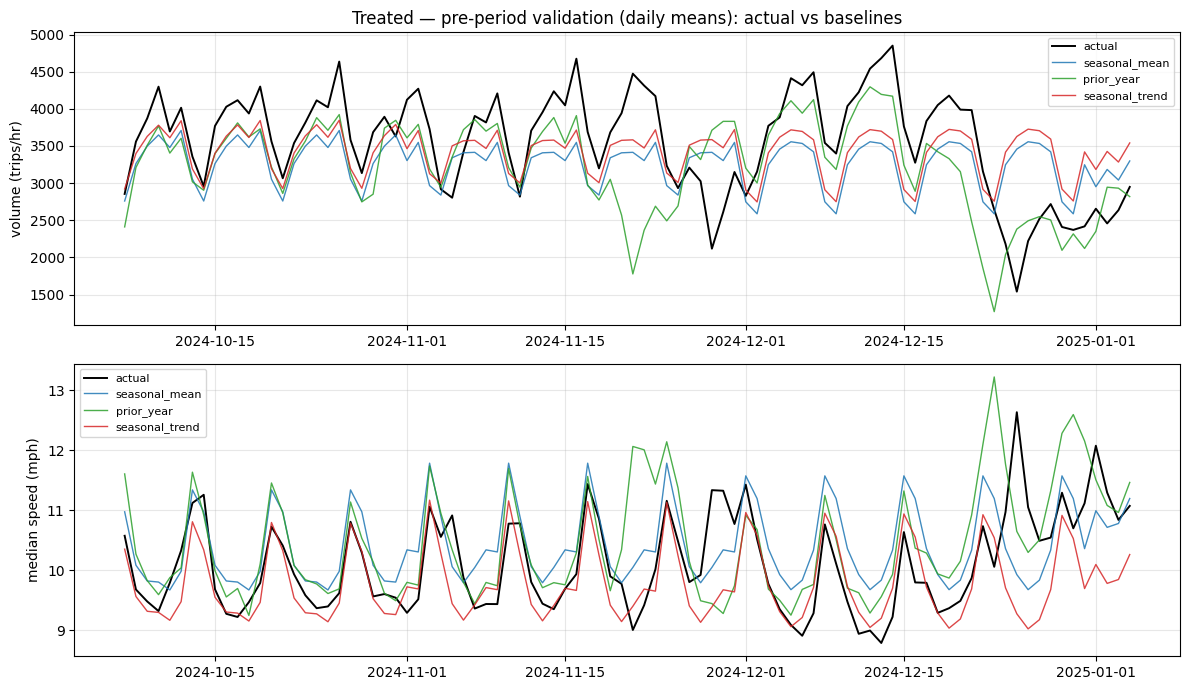

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, tgt, lab in zip(axes, PRIMARY, ["volume (trips/hr)", "median speed (mph)"]):
    val, _ = preds_store[("treated", tgt, "seasonal_trend")]
    dates  = val["datetime"].dt.date.to_numpy()
    actual = pd.DataFrame({"date": dates, "y": val[tgt].to_numpy()}).groupby("date")["y"].mean()
    ax.plot(actual.index, actual.values, color="k", lw=1.4, label="actual")
    for name, c in [("seasonal_mean","tab:blue"), ("prior_year","tab:green"),
                    ("seasonal_trend","tab:red")]:
        _, yhat = preds_store[("treated", tgt, name)]
        s = pd.DataFrame({"date": dates, "y": yhat}).groupby("date")["y"].mean()
        ax.plot(s.index, s.values, c=c, lw=1, alpha=.85, label=name)
    ax.set_ylabel(lab); ax.legend(fontsize=8); ax.grid(alpha=.3)
axes[0].set_title("Treated — pre-period validation (daily means): actual vs baselines")
fig.tight_layout(); plt.show()